# **CAPEI** WRDS Signal Reconstruction

In [ ]:
# !pip install wrds
# !pip install fredapi

In [ ]:
import os
import pandas as pd
from datetime import datetime
import getpass
from wrds import Connection
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from pathlib import Path
from fredapi import Fred
import warnings
warnings.filterwarnings('ignore')

In [ ]:
db = Connection()

Enter your WRDS username [root]:robinglee
Enter your password:··········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: y
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [ ]:
# Date range
start_year = 2000
end_year = 2024
# Set to False to match WRDS signals_raw_plus
CPI_ADJUSTED = False
# fred api key (optional)
fred_api=''

## Background

1. **Earnings Measure**

    Shiller uses S&P 500 aggregate reported earnings per share for the index as a whole. WRDS CAPEI uses `ibq` (income before extraordinary items) at the individual firm level (excludes unusual one-time items).

2. **Inflation Adjustment**

    Shiller CPI-adjusts all historical earnings to current dollars before averaging. WRDS CAPEI uses nominal earnings with no CPI adjustment. The long averaging window implicitly smooths some inflation effects but does not formally correct for them.

3. **Window Length**

    Shiller uses a 10-year (40-quarter) average. WRDS uses a 5-year (20-quarter) average. `capei` is more responsive to recent earnings changes.

4. **Signal Direction**

    Shiller's CAPE is expressed as P/E (price divided by earnings), so higher values mean more expensive. WRDS CAPEI is expressed as E/P (earnings yield), so higher values mean cheaper. They are inverses of each other.

5. **Level of Application**

    Shiller's CAPE is an index-level macro valuation metric used to assess whether the overall market is cheap or expensive. WRDS CAPEI is a firm-level cross-sectional signal used to rank individual stocks against each other for portfolio construction.

6. **Practical Implication**

    Because WRDS drops the CPI adjustment and halves the window, it is closer to a medium-term earnings yield than a true cyclically adjusted ratio in Shiller's sense. The WRDS version is better suited for stock selection while Shiller's version is better suited for market timing.

## Manual WRDS Factor Reconstruction

Uses price scaled by 5-year quarterly net income before
extraordinary items and discontinued operations as the
basic valuation metric

In [ ]:
# Fundq (quarterly)
# Income Before Extraordinary Items - Quarterly
fundq_query = f"""
SELECT gvkey, datadate, fyearq, fqtr, fyr, ibq
FROM comp.fundq
WHERE datadate >= '{start_year - 6}-01-01'
  AND datadate <= '{end_year}-12-31'
  AND indfmt = 'INDL'
  AND datafmt = 'STD'
  AND popsrc = 'D'
  AND consol = 'C'
ORDER BY gvkey, datadate
"""
fundq = db.raw_sql(fundq_query)
fundq['datadate'] = pd.to_datetime(fundq['datadate'])

# deduplicate: one row per gvkey/fyr/fyearq/fqtr (keep latest restatement)
fundq = (
    fundq
    .sort_values('datadate')
    .drop_duplicates(subset=['gvkey', 'fyr', 'fyearq', 'fqtr'], keep='last')
)

# CPI adjustment (optional)
if CPI_ADJUSTED:
  fred = Fred(api_key=fred_api)
  cpi = fred.get_series('CPIAUCSL', observation_start='1990-01-01')
  cpi_df = cpi.to_frame(name='cpi').reset_index()
  cpi_df.columns = ['month_date', 'cpi']
  cpi_df['month_date'] = cpi_df['month_date'] + pd.offsets.MonthEnd(0)
  # Get most recent CPI for current dollar conversion
  current_cpi = cpi_df['cpi'].iloc[-1]
  cpi_df['real_multiplier'] = current_cpi / cpi_df['cpi']
  # adjust income
  fundq['month_date'] = fundq['datadate'] + pd.offsets.MonthEnd(0)
  fundq = fundq.merge(cpi_df[['month_date', 'cpi']], on='month_date', how='left')
  fundq['real_multiplier'] = cpi_df['real_multiplier']
  fundq['ibq_adjusted'] = fundq['ibq'] * fundq['real_multiplier']
else:
    fundq['ibq_adjusted'] = fundq['ibq']  # WRDS is nominal (no adjustment)

# trailing 12 months IBq (sum 4 quarters), then 20-quarter moving avg, min 13 periods
def calc_quarterly_capei(group):
    group = group.sort_values('datadate')
    # fqtr is 1, 2, 3, 4 for each quarter of the fiscal year (should be 10)
    group['fqtr_sum'] = group['fqtr'].rolling(window=4, min_periods=4).sum()
    # sum ibq_adjusted over the last 4 quarters = Trailing Twelve Months earnings
    group['ttm_ibq']  = group['ibq_adjusted'].rolling(window=4, min_periods=4).sum()
    # ensure 4 consecutive quarters
    group.loc[group['fqtr_sum'] != 10, 'ttm_ibq'] = np.nan
    # 20-quarter (5-year) moving average of the TTM earnings (need at least 13 valid TTM values)
    group['capei_quarterly'] = (
        group['ttm_ibq']
        .rolling(window=20, min_periods=13)
        .mean()
    )
    return group.drop(columns='fqtr_sum')

fundq_final = fundq.groupby(['gvkey', 'fyr'], group_keys=False).apply(calc_quarterly_capei)

# public date (2-month lag) to avoid look-ahead bias
fundq_final['public_date'] = (
    fundq_final['datadate'] + pd.DateOffset(months=2) + pd.offsets.MonthEnd(0)
)

# deduplicate on public_date per gvkey before link table merge
fundq_final = (
    fundq_final
    .sort_values(['gvkey', 'public_date', 'datadate'])
    .drop_duplicates(subset=['gvkey', 'public_date'], keep='last')
)

# compustat and crsp link table
ccm_query = """
SELECT gvkey, lpermno AS permno, linktype, linkprim, linkdt, linkenddt
FROM crsp.ccmxpf_lnkhist
WHERE linktype IN ('LC', 'LU', 'LS')
  AND linkprim IN ('P', 'C')
"""
ccm = db.raw_sql(ccm_query)
ccm['linkdt']    = pd.to_datetime(ccm['linkdt'])
ccm['linkenddt'] = pd.to_datetime(ccm['linkenddt']).fillna(pd.Timestamp('2099-12-31'))
# keep most trustworthy links
link_priority = {'LC': 1, 'LU': 2, 'LS': 3}
ccm['priority'] = ccm['linktype'].map(link_priority)
ccm = (
    ccm
    .sort_values('priority')
    .drop_duplicates(subset=['gvkey', 'permno', 'linkdt'], keep='first')
    .drop(columns='priority')
)

# CRSP monthly stock file
crsp_query = f"""
SELECT permno, date, prc, shrout, ret
FROM crsp.msf
WHERE date >= '{start_year}-01-01' AND date <= '{end_year}-12-31'
"""
crsp = db.raw_sql(crsp_query)
crsp['date']       = pd.to_datetime(crsp['date'])
crsp['month_date'] = crsp['date'] + pd.offsets.MonthEnd(0)
crsp['mktcap']     = crsp['prc'].abs() * crsp['shrout'] / 1000  # convert to millions
crsp['permno']     = crsp['permno'].astype(int)

# WRDS also uses compustat as fall back when CRSP data is missing
secm_query = f"""
SELECT gvkey, datadate, prccm, cshom
FROM comp.secm
WHERE datadate >= '{start_year}-01-01' AND datadate <= '{end_year}-12-31'
  AND tpci = '0' AND fic = 'USA' AND primiss = 'P'
"""
secm = db.raw_sql(secm_query)
secm['datadate']   = pd.to_datetime(secm['datadate'])
secm['month_date'] = secm['datadate'] + pd.offsets.MonthEnd(0)
secm['mcap_comp']  = secm['prccm'] * secm['cshom'] / 1_000_000 # cshom in raw counts, convert to millions

# merge fundq and CCM, filter on valid link dates
merged = fundq_final.merge(ccm, on='gvkey', how='inner')
merged = merged[
    (merged['datadate'] >= merged['linkdt']) &
    (merged['datadate'] <= merged['linkenddt'])
].copy()

merged['permno'] = merged['permno'].astype(int)

# deduplicate on permno/public_date after link table merge
merged = (
    merged
    .sort_values(['permno', 'public_date', 'datadate'])
    .drop_duplicates(subset=['permno', 'public_date'], keep='last')
    .sort_values('public_date')
)

# use merge_asof to carry forward last available earnings to each CRSP month
cape_combined = pd.merge_asof(
    crsp.sort_values('month_date'),
    merged[['permno', 'public_date', 'capei_quarterly', 'gvkey']],
    left_on='month_date',
    right_on='public_date',
    by='permno',
    direction='backward'
)

# WRDS has a staleness filter to drop if earnings are >12 months stale
cape_combined['days_stale'] = (
    cape_combined['month_date'] - cape_combined['public_date']
).dt.days
cape_combined = cape_combined[cape_combined['days_stale'] <= 365].copy()

# merge compustat market cap as fallback
cape_combined = cape_combined.merge(
    secm[['gvkey', 'month_date', 'mcap_comp']],
    on=['gvkey', 'month_date'],
    how='left'
)

# CRSP first, compustat fallback
cape_combined['mktcap'] = cape_combined['mktcap'].combine_first(cape_combined['mcap_comp'])

# calculkate CAPEI: earnings yield = avg_ttm_ibq / mktcap
cape_combined['capei'] = cape_combined['capei_quarterly'] / cape_combined['mktcap']
cape_valid = cape_combined[
    np.isfinite(cape_combined['capei']) & (cape_combined['capei'] > 0)
].copy()

In [ ]:
cape_valid

,permno,date,prc,shrout,ret,month_date,mktcap,public_date,capei_quarterly,gvkey,days_stale,mcap_comp,capei
0,10001,2000-01-31,8.125,2450.0,-0.044118,2000-01-31,19.90625,1999-11-30,1.375750,012994,62.0,19.955,0.069111
1,83547,2000-01-31,8.875,5232.0,-0.013889,2000-01-31,46.434,1999-11-30,5.165846,062895,62.0,46.434,0.111251
11,83529,2000-01-31,2.6875,5451.0,0.246377,2000-01-31,14.649563,1999-11-30,0.724722,062107,62.0,14.8565,0.049471
12,83528,2000-01-31,5.5,6275.0,0.073171,2000-01-31,34.5125,1999-11-30,0.960125,062859,62.0,34.5125,0.02782
14,83526,2000-01-31,24.375,14470.0,-0.008475,2000-01-31,352.70625,1999-12-31,13.621438,062748,31.0,352.70625,0.03862
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2151504,20347,2024-12-31,5.53,166699.0,0.059387,2024-12-31,921.84547,2024-11-30,50.222647,037646,31.0,921.84547,0.054481
2151539,20107,2024-12-31,7.55,148937.0,-0.065477,2024-12-31,1124.47435,2024-11-30,980.810850,222648,31.0,<NA>,0.872239
2151575,20190,2024-12-31,131.41,432877.0,-0.034531,2024-12-31,56884.36657,2024-11-30,438.496150,037460,31.0,56884.36657,0.007709
2151581,20188,2024-12-31,51.89,91373.0,-0.116337,2024-12-31,4741.34497,2024-11-30,708.300000,021431,31.0,4741.34497,0.149388


## WRDS Pre-Made CAPEI

In [ ]:
backtest_plus_query = f"""
SELECT fdate, permno, capei
FROM wrdsapps_backtest_plus.signals_raw_plus
WHERE fdate >= '{start_year}-01-01'
  AND fdate <= '{end_year}-12-31'
"""
capei_wrds = db.raw_sql(backtest_plus_query)
capei_wrds['fdate'] = pd.to_datetime(capei_wrds['fdate'])
capei_wrds['fdate'] = capei_wrds['fdate'] + pd.offsets.MonthEnd(0)
capei_wrds = capei_wrds.rename(columns={'fdate': 'month_date', 'capei': 'cape_wrds'})

In [ ]:
capei_wrds.head()

,month_date,permno,cape_wrds
0,2000-01-31,10001,0.070117
1,2000-01-31,10002,0.046505
2,2000-01-31,10009,0.117992
3,2000-01-31,10012,-0.013388
4,2000-01-31,10016,-0.02479


## Comparison

In [ ]:
test = cape_valid[cape_valid['permno'] == 12490].sort_values('month_date')
ref  = capei_wrds[capei_wrds['permno'] == 12490].sort_values('month_date')
print(test[['month_date','capei']].head(20))
print(ref[['month_date','cape_wrds']].head(20))

       month_date     capei
5099   2000-01-31   0.02666
13330  2000-02-29  0.030391
21491  2000-03-31  0.026594
29569  2000-04-30  0.028144
37753  2000-05-31   0.03058
45886  2000-06-30  0.029969
53925  2000-07-31  0.029203
62091  2000-08-31  0.025555
70183  2000-09-30  0.029985
78215  2000-10-31  0.034246
86386  2000-11-30  0.037236
94468  2000-12-31  0.041108
102411 2001-01-31  0.031198
110362 2001-02-28  0.036093
118289 2001-03-31  0.037352
126140 2001-04-30  0.031202
133925 2001-05-31  0.033773
141645 2001-06-30  0.033414
149277 2001-07-31  0.035889
156908 2001-08-31  0.039294
       month_date  cape_wrds
498    2000-01-31   0.026473
7076   2000-02-29    0.03196
13589  2000-03-31   0.027967
20136  2000-04-30   0.029597
26670  2000-05-31   0.030416
33153  2000-06-30   0.029809
39661  2000-07-31   0.029047
46157  2000-08-31   0.025434
52592  2000-09-30   0.029843
59099  2000-10-31   0.034084
65590  2000-11-30   0.037083
71988  2000-12-31   0.040939
78363  2001-01-31   0.031069
84724 

In [ ]:
# Merge and compute error statistics
compare = test.merge(ref, on='month_date', how='inner')
compare['abs_diff'] = (compare['capei'] - compare['cape_wrds']).abs()
compare['rel_diff'] = compare['abs_diff'] / compare['cape_wrds']

print(compare[['month_date', 'capei', 'cape_wrds', 'abs_diff', 'rel_diff']].to_string())
print(f"\nMean absolute diff : {compare['abs_diff'].mean():.6f}")
print(f"Mean relative diff : {compare['rel_diff'].mean():.2%}")
print(f"Max relative diff  : {compare['rel_diff'].max():.2%}")
print(f"Correlation        : {compare['capei'].corr(compare['cape_wrds']):.6f}")

    month_date     capei  cape_wrds  abs_diff  rel_diff
0   2000-01-31   0.02666   0.026473  0.000187  0.007062
1   2000-02-29  0.030391    0.03196  0.001569  0.049095
2   2000-03-31  0.026594   0.027967  0.001373  0.049095
3   2000-04-30  0.028144   0.029597  0.001453  0.049095
4   2000-05-31   0.03058   0.030416  0.000163  0.005368
5   2000-06-30  0.029969   0.029809   0.00016  0.005368
6   2000-07-31  0.029203   0.029047  0.000156  0.005368
7   2000-08-31  0.025555   0.025434  0.000121  0.004755
8   2000-09-30  0.029985   0.029843  0.000142  0.004755
9   2000-10-31  0.034246   0.034084  0.000162  0.004755
10  2000-11-30  0.037236   0.037083  0.000153  0.004126
11  2000-12-31  0.041108   0.040939  0.000169  0.004126
12  2001-01-31  0.031198   0.031069  0.000128  0.004126
13  2001-02-28  0.036093   0.038292  0.002199  0.057424
14  2001-03-31  0.037352   0.039628  0.002276  0.057424
15  2001-04-30  0.031202   0.033103  0.001901  0.057424
16  2001-05-31  0.033773   0.033655  0.000118  0

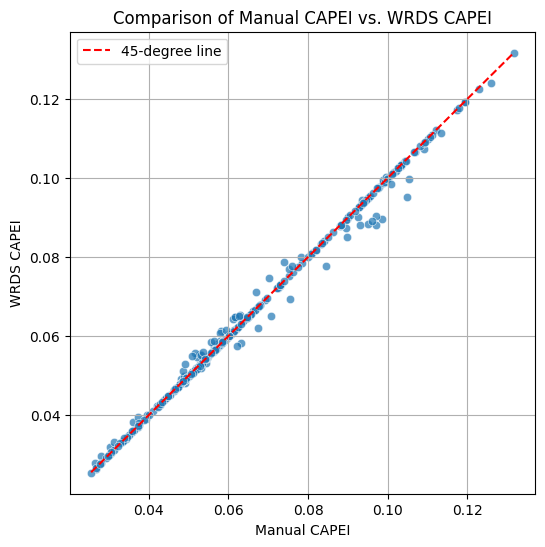

In [ ]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x='capei', y='cape_wrds', data=compare, alpha=0.7)
plt.plot([compare['capei'].min(), compare['capei'].max()],
         [compare['capei'].min(), compare['capei'].max()],
         color='red', linestyle='--', label='45-degree line')
plt.title('Comparison of Manual CAPEI vs. WRDS CAPEI')
plt.xlabel('Manual CAPEI')
plt.ylabel('WRDS CAPEI')
plt.legend()
plt.grid(True)
plt.show()

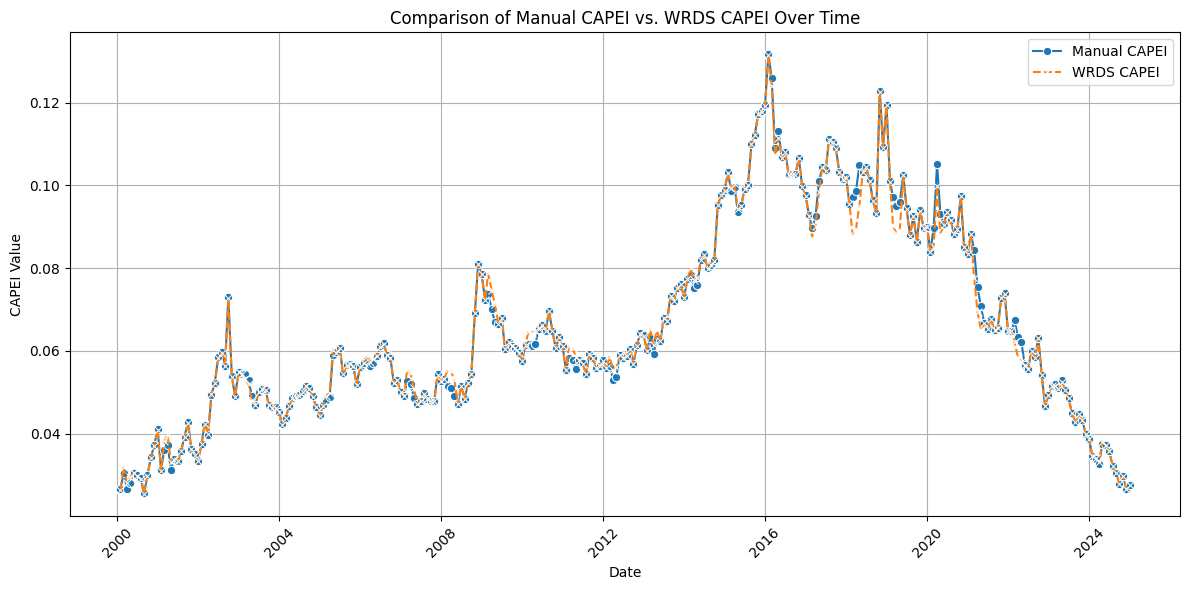

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='month_date', y='capei', data=compare, label='Manual CAPEI', marker='o', linestyle='-')
sns.lineplot(x='month_date', y='cape_wrds', data=compare, label='WRDS CAPEI', marker='x', linestyle='--')
plt.title('Comparison of Manual CAPEI vs. WRDS CAPEI Over Time')
plt.xlabel('Date')
plt.ylabel('CAPEI Value')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()